In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from google.colab import drive
drive.mount('/content/drive')
bfsighting = pd.read_csv('/content/drive/MyDrive/Bigfoot Dataset/bfro_reports_geocoded.csv')
bfsighting.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 35.5 MB/s eta 0:00:00
Mounted at /content/drive


,index,observed,location_details,county,state,season,title,latitude,longitude,date,...,moon_phase,precip_intensity,precip_probability,precip_type,pressure,summary,uv_index,visibility,wind_bearing,wind_speed
0,0,I was canoeing on the Sipsey river in Alabama....,NaN,Winston County,Alabama,Summer,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Ed L. was salmon fishing with a companion in P...,East side of Prince William Sound,Valdez-Chitina-Whittier County,Alaska,Fall,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"While attending U.R.I in the Fall of 1974,I wo...","Great swamp area, Narragansett Indians",Washington County,Rhode Island,Fall,Report 6496: Bicycling student has night encou...,41.45,-71.5,1974-09-20,...,0.16,0.0,0.0,NaN,1020.61,Foggy until afternoon.,4.0,2.75,198.0,6.92
3,3,"Hello, My name is Doug and though I am very re...",I would rather not have exact location (listin...,York County,Pennsylvania,Summer,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,It was May 1984. Two friends and I were up in ...,"Logging roads north west of Yamhill, OR, about...",Yamhill County,Oregon,Spring,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


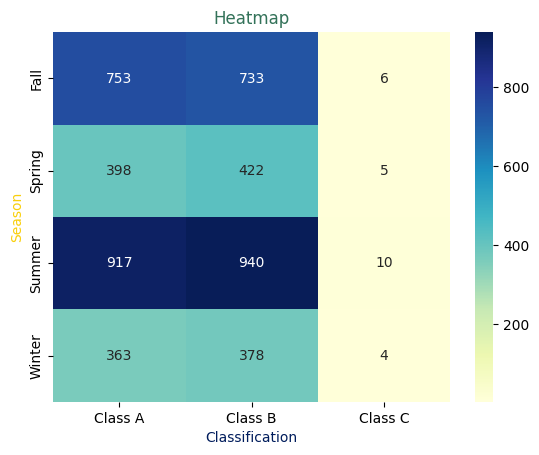

In [ ]:
#TAKE!!!
#season of the year and bigfoot sighting class heatmap, eliminate unknown
bfsighting_heatmap = bfsighting[bfsighting['season'] != 'Unknown']
sns.heatmap(bfsighting_heatmap.groupby(['season', 'classification']).size().unstack(), cmap='YlGnBu', annot=True, fmt='d')
plt.xlabel('Classification',color='#001c5c')
plt.ylabel('Season',color='#f9cf0b')
plt.title('Heatmap',color='#337259')
plt.show()

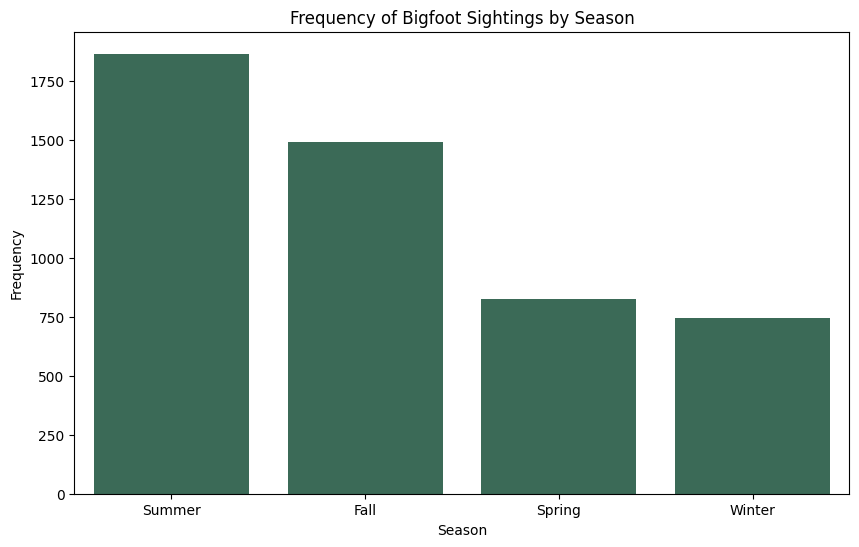

In [ ]:
#bar chart of frequency by season
plt.figure(figsize=(10, 6))
#filter out NaN
bfsighting = bfsighting[bfsighting['season'] != 'Unknown']
sns.countplot(x='season', data=bfsighting, color='#337259')
plt.title('Frequency of Bigfoot Sightings by Season')
plt.xlabel('Season')
plt.ylabel('Frequency')
plt.show()

/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py

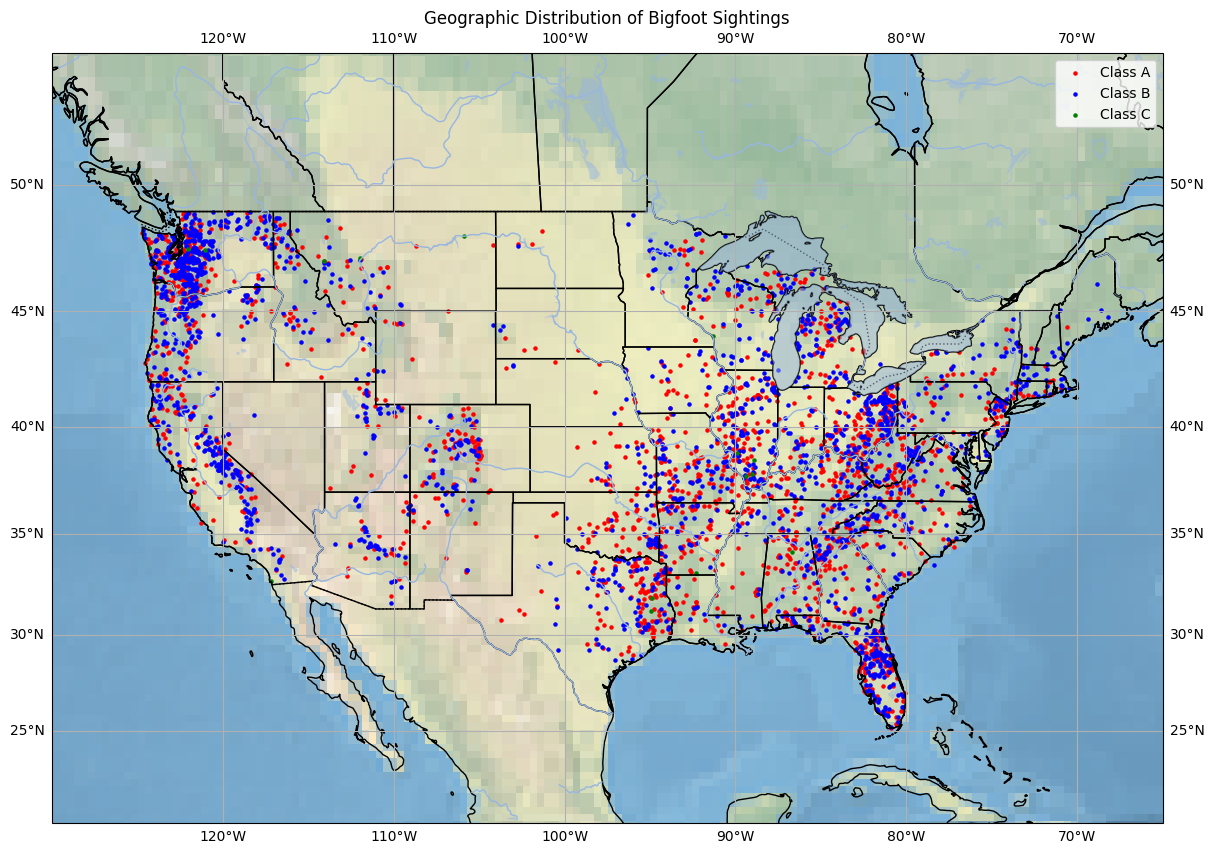

In [ ]:
#TAKE!!!
bfsightinggeo = bfsighting[bfsighting['latitude'] != 'NoData']
bfsightinggeo = bfsightinggeo[bfsightinggeo['longitude'] != 'NoData']

bfsightinggeo['latitude'] = pd.to_numeric(bfsightinggeo['latitude'])
bfsightinggeo['longitude'] = pd.to_numeric(bfsightinggeo['longitude'])

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())

ax.stock_img()

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle='-')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

ax.set_extent([-130, -65, 20, 50])

class_a = bfsightinggeo[bfsightinggeo['classification'] == 'Class A']
class_b = bfsightinggeo[bfsightinggeo['classification'] == 'Class B']
class_c = bfsightinggeo[bfsightinggeo['classification'] == 'Class C']

plt.scatter(class_a['longitude'], class_a['latitude'], color='red', marker='o', s=5, label='Class A', transform=ccrs.PlateCarree())
plt.scatter(class_b['longitude'], class_b['latitude'], color='blue', marker='o', s=5, label='Class B', transform=ccrs.PlateCarree())
plt.scatter(class_c['longitude'], class_c['latitude'], color='green', marker='o', s=5, label='Class C', transform=ccrs.PlateCarree())

ax.set_title('Geographic Distribution of Bigfoot Sightings')
plt.legend()
plt.show()

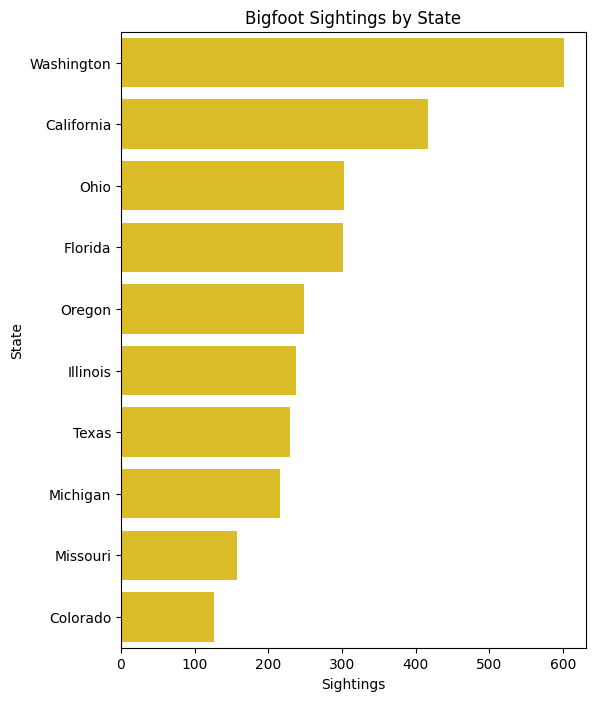

In [ ]:
bfsightingstate = bfsighting[bfsighting['state'] != 'NoData']

plt.figure(figsize=(6, 8))
sns.countplot(y='state', data=bfsightingstate, order=bfsightingstate['state'].value_counts().iloc[:10].index, color='#f9cf0b') # Use 'state' instead of 'state_name'
plt.title('Bigfoot Sightings by State')
plt.xlabel('Sightings')
plt.ylabel('State')
plt.show()

<Axes: xlabel='count', ylabel='summary'>

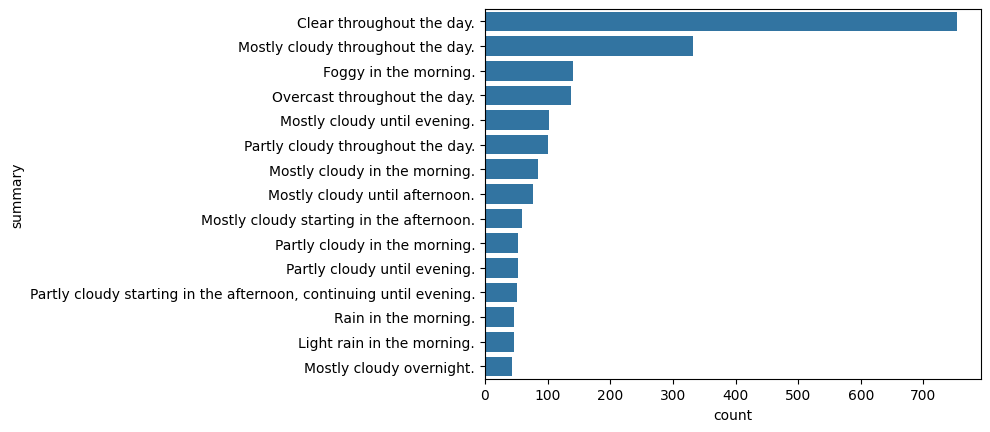

In [ ]:
bfsightingsummary = bfsighting[bfsighting['summary'] != 'NoData']
sns.countplot(y='summary', data=bfsightingsummary, order=bfsightingsummary['summary'].value_counts().iloc[:15].index)


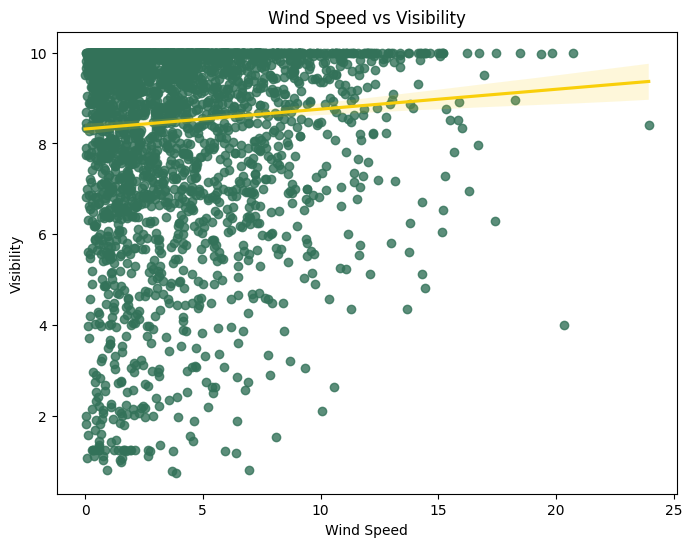

In [ ]:
#TAKE!!!
bfsightingviscc = bfsighting[bfsighting['wind_speed'] != 'NoData'][bfsighting['visibility'] != 'NoData']

plt.figure(figsize=(8, 6))
sns.regplot(x='wind_speed', y='visibility', data=bfsightingviscc, color = '#337259', line_kws={'color': '#f9cf0b'})
plt.title('Wind Speed vs Visibility')
plt.xlabel('Wind Speed')
plt.ylabel('Visibility')
plt.show()

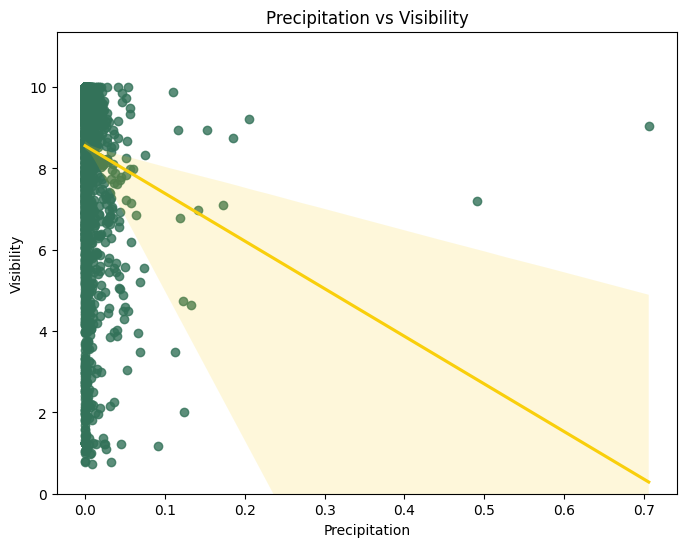

In [ ]:
#TAKE!!!
bfsightingviscc = bfsighting[bfsighting['precip_intensity'] != 'NoData'][bfsighting['visibility'] != 'NoData']


plt.figure(figsize=(8, 6))
sns.regplot(x='precip_intensity', y='visibility', data=bfsightingviscc, color = '#337259', line_kws={'color': '#f9cf0b'})
plt.title('Precipitation vs Visibility')
plt.xlabel('Precipitation')
plt.ylabel('Visibility')
plt.ylim(0)

plt.show()

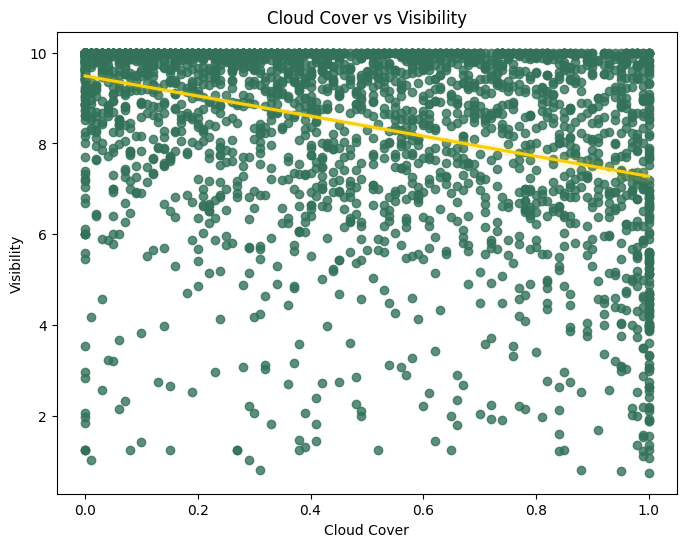

In [ ]:
#TAKE!!!
bfsightingviscc = bfsighting[bfsighting['cloud_cover'] != 'NoData'][bfsighting['visibility'] != 'NoData']


plt.figure(figsize=(8, 6))
sns.regplot(x='cloud_cover', y='visibility', data=bfsightingviscc, color = '#337259', line_kws={'color': '#f9cf0b'})
plt.title('Cloud Cover vs Visibility')
plt.xlabel('Cloud Cover')
plt.ylabel('Visibility')
plt.show()

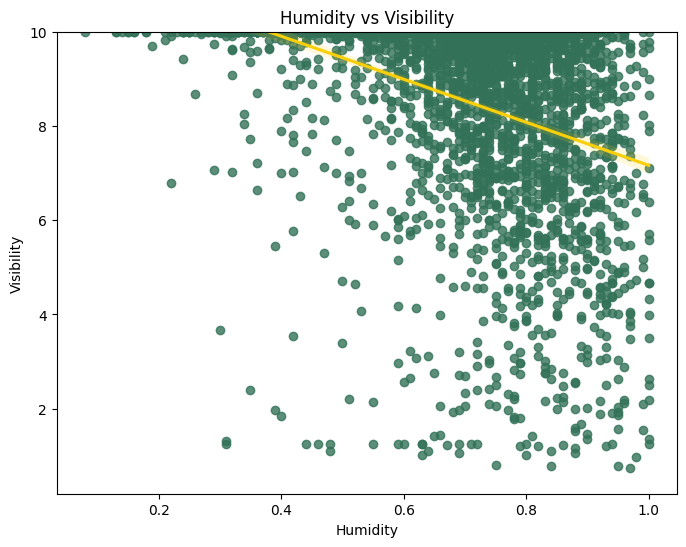

In [ ]:
bfsightingviscc = bfsighting[bfsighting['humidity'] != 'NoData'][bfsighting['visibility'] != 'NoData']


plt.figure(figsize=(8, 6))
sns.regplot(x='humidity', y='visibility', data=bfsightingviscc, color = '#337259', line_kws={'color': '#f9cf0b'})
plt.title('Humidity vs Visibility')
plt.xlabel('Humidity')
plt.ylabel('Visibility')
plt.ylim(ymax=10)

plt.show()

In [ ]:
#TAKE!!!
bfsightingviscc = bfsighting[bfsighting['precip_intensity'] != 'NoData'][bfsighting['visibility'] != 'NoData']
plt.figure(figsize=(8, 6))
sns.regplot(x='precip_intensity', y='visibility', data=bfsightingviscc, color = '#337259', line_kws={'color': '#f9cf0b'})
plt.title('Precipitation vs Visibility')
plt.xlabel('Precipitation')
plt.ylabel('Visibility')
plt.show()

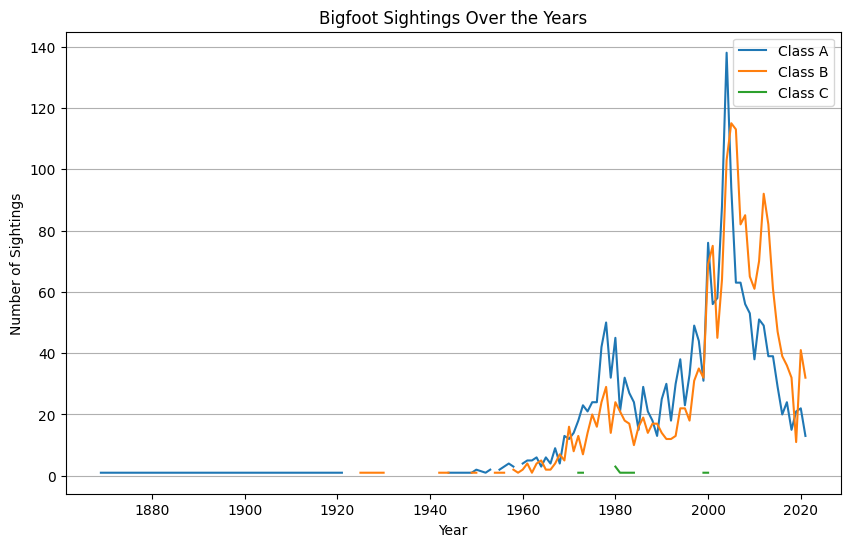

In [ ]:


bfsighting['date'] = pd.to_datetime(bfsighting['date'])
bfsighting['year'] = bfsighting['date'].dt.year
sightings_by_year_class = bfsighting.groupby(['year', 'classification']).size().unstack()

plt.figure(figsize=(10, 6))

for classification in sightings_by_year_class.columns:
  plt.plot(sightings_by_year_class.index,
           sightings_by_year_class[classification],
           label=classification)

plt.title('Bigfoot Sightings Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Sightings')
plt.legend()
plt.grid(axis='y')
plt.show()

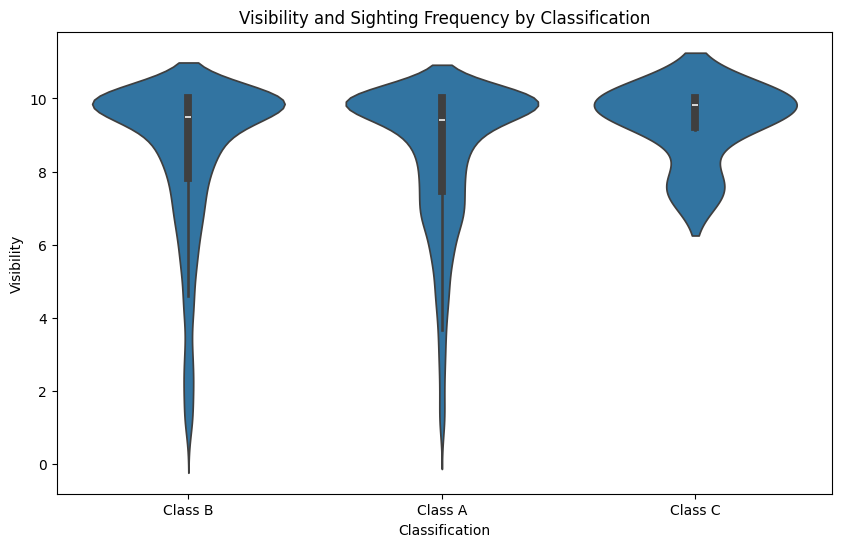

In [ ]:
#TAKE!!!
plt.figure(figsize=(10, 6))
sns.violinplot(x='classification', y='visibility', data=bfsighting)
plt.title('Visibility and Sighting Frequency by Classification')
plt.xlabel('Classification')
plt.ylabel('Visibility')
plt.plot(color='#337259')
plt.show()